# Canonical Model 01 · Packages and Observations

Inspect the package topology and the canonical **observation** layer. The same
named targets that drive the plots in 02 are the exact targets PEST calibrates
in 04–06 — one definition, reused everywhere.

> **Observation principle:** targets belong to the model. Heads capture the
> infiltration-pond mound, the regional center, and both pumping responses; DRN
> targets aggregate the north and south **seepage** spring slopes; LAK and SFR
> targets read real MF6 observation output for lake stage, stream stage, and
> routed flow.

In [1]:
import sys
from pathlib import Path

# Make the in-repo `src/` importable when myflopy is not pip-installed.
src = Path.cwd().parents[2] / 'src'
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))
import myflopy as mf
from canonical_notebook_style import notebook_header

notebook_header('01', 'Packages and Observations', 'Named physical features become reusable observations.')

model = mf.build_canonical_model(Path('../artifacts/canonical_observations') / 'gwf',
                                 config=mf.CanonicalModelConfig.validation())
success, report = model.run_simulation()
assert success, '\n'.join(report[-30:])

print('packages :', sorted(str(n).lower() for n in model.gwf.package_names))
print('targets  :', list(model.targets.keys()))

VoronoiGrid initializing.


Voronoi grid initialized.


getting connectivity properties (iac, ja, cl12, hwva, nja)


C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:278: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model viz_prt_master...
    writing model name file...
    writing package disv...
    writing package ic...
    writing package npf...


...

    Solving:  Stress period:     5    Time step:     2


    Solving:  Stress period:     6    Time step:     1


    Solving:  Stress period:     6    Time step:     2


 
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2026/06/22 21:49:21
 Elapsed run time:  7.058 Seconds
 
 Normal termination of simulation.

Success is:  True
packages : ['chd', 'disv', 'drn', 'drn_flow_obs', 'ghb', 'gwf_obs', 'ic', 'lak', 'lak_obs', 'mvr', 'npf', 'oc', 'rch', 'sfr', 'sfr_obs', 'sto', 'uzf', 'wel']
targets  : ['drn_flow', 'heads', 'lake_stage', 'sfr_flow', 'sfr_stage']


C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:278: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(


## The observation network

Each target is a small table indexed by time (or stress period). They are the
model's *measurable* outputs:

- **heads** — `pond_mound`, `regional_center`, `shallow_pumping`, `deep_pumping`
- **drn_flow** — `north_springs`, `south_springs` (aquifer **seepage**)
- **lake_stage** — `valley_lake`
- **sfr_stage** — `sfr_upstream`, `sfr_midpoint`
- **sfr_flow** — `sfr_midflow`, `sfr_outflow` (routed discharge toward the lake)

In [2]:
from IPython.display import display

display(model.targets.heads.simulated_heads())
display(model.targets.drn_flow.simulated_series())
display(model.targets.lake_stage.simulated_series())
display(model.targets.sfr_stage.simulated_series())
display(model.targets.sfr_flow.simulated_series())

# Compact magnitudes: head change at each well and peak seepage at each slope.
mf.canonical_feature_signals(model)

,per,deep_pumping,pond_mound,regional_center,shallow_pumping
0,0,127.569579,135.228368,96.522847,107.362734
1,1,123.681999,135.892919,97.166313,103.075064
2,2,123.711642,135.926032,97.443462,95.053506
3,3,116.615535,135.77519,97.577084,93.592476
4,4,116.565224,135.634259,97.79101,100.774096
5,5,123.624885,135.550798,97.848736,102.144443


,time,north_springs,south_springs
0,15.0,-4960.059140,-4552.825331
1,30.0,-4960.057549,-4552.823847
2,45.0,-5335.806760,-4905.694280
3,60.0,-5614.616903,-5167.443289
4,75.0,-5799.111542,-5340.199526
5,90.0,-5881.311664,-5415.080332
6,105.0,-5847.425059,-5386.734725
7,120.0,-5778.993490,-5324.823942
8,135.0,-5692.642175,-5247.190235
9,150.0,-5611.861276,-5172.888735


,time,valley_lake
0,15.0,104.919594
1,30.0,104.919594
2,45.0,105.064285
3,60.0,105.136365
4,75.0,105.171862
5,90.0,105.187359
6,105.0,105.067433
7,120.0,105.011432
8,135.0,104.852061
9,150.0,104.774812


,time,sfr_upstream,sfr_midpoint
0,15.0,119.595198,109.097421
1,30.0,119.595198,109.097421
2,45.0,119.602347,109.104385
3,60.0,119.602911,109.104953
4,75.0,119.603173,109.105193
5,90.0,119.603217,109.105219
6,105.0,119.596794,109.099340
7,120.0,119.596602,109.099135
8,135.0,119.589817,109.092969
9,150.0,119.589636,109.092801


,time,sfr_midflow,sfr_outflow
0,15.0,-50809.330857,-49108.056033
1,30.0,-50809.326996,-49108.052175
2,45.0,-57709.843090,-56001.431441
3,60.0,-58320.803389,-56611.792926
4,75.0,-58580.138970,-56870.875097
5,90.0,-58608.834372,-56899.542488
6,105.0,-52395.502913,-50692.620364
7,120.0,-52183.892738,-50481.236894
8,135.0,-45953.511650,-44257.150469
9,150.0,-45788.519490,-44092.336449


{'head_change': {'deep_pumping': 11.004355237158023,
  'pond_mound': 0.6976642781455666,
  'regional_center': 1.3258889829139946,
  'shallow_pumping': 13.770258022371323},
 'seepage_peak': {'north_springs': 5881.311663798089,
  'south_springs': 5415.080332325385}}

## Plot the signals

**What to look for:** the pond-mound head rises seasonally without overwhelming
the regional pattern; both pumping wells draw their heads down; and the two
seepage slopes discharge with *different* time series (they tap different
aquifers). These transient signals are what the calibration must reproduce.

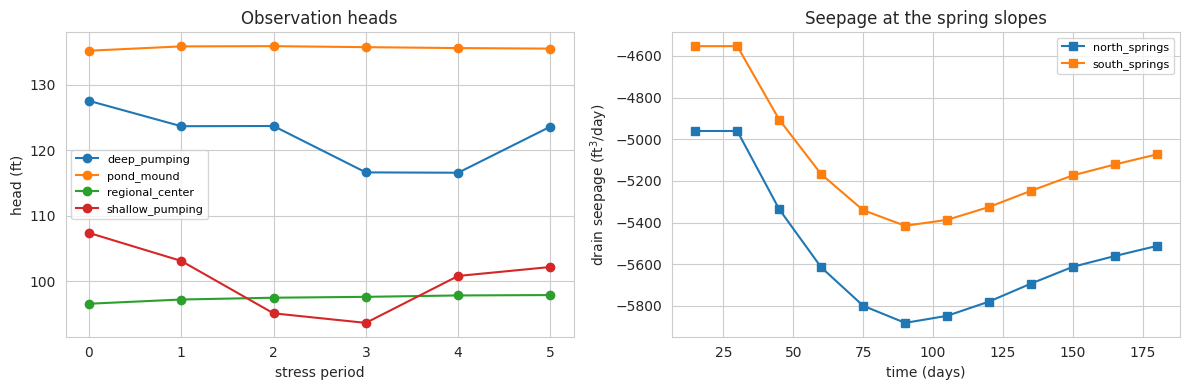

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

heads = model.targets.heads.simulated_heads()
seep = model.targets.drn_flow.simulated_series()

with sns.axes_style('whitegrid'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for col in [c for c in heads.columns if c != 'per']:
    ax1.plot(heads['per'], heads[col], marker='o', label=col)
ax1.set_xlabel('stress period'); ax1.set_ylabel('head (ft)')
ax1.set_title('Observation heads'); ax1.legend(fontsize=8)
for col in [c for c in seep.columns if c != 'time']:
    ax2.plot(seep['time'], seep[col], marker='s', label=col)
ax2.set_xlabel('time (days)'); ax2.set_ylabel('drain seepage (ft$^3$/day)')
ax2.set_title('Seepage at the spring slopes'); ax2.legend(fontsize=8)
fig.tight_layout()

## Questions worth asking

- Does the infiltration-pond head rise without dominating the regional gradient?
- Do both seepage slopes discharge, and do their series differ between aquifers?
- Are lake and stream observations real MF6 observation output (not post-hoc)?
- Can every target pass straight into a calibration plot and PEST setup?

Continue to **02 · Visual Diagnostics** to see why these signals matter spatially.